<a href="https://colab.research.google.com/github/Lekhanapriya-295/Machine_learning_models/blob/main/Movie_recommended_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving movie_recommendation_dataset_3600.csv to movie_recommendation_dataset_3600 (1).csv


In [ ]:
df = pd.read_csv("movie_recommendation_dataset_3600.csv")
print("Shape:", df.shape)

Shape: (3635, 19)


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column Names:")
print(df.columns.tolist())

Rows: 3635
Columns: 19
Column Names:
['movie_id', 'title', 'genre', 'language', 'country', 'release_year', 'runtime_minutes', 'certificate', 'imdb_rating', 'vote_count', 'popularity_score', 'budget_usd', 'revenue_usd', 'director', 'lead_actor', 'user_age_rating', 'weather', 'director_favorite_color', 'data_entry_date']


In [ ]:
df.head()

,movie_id,title,genre,language,country,release_year,runtime_minutes,certificate,imdb_rating,vote_count,popularity_score,budget_usd,revenue_usd,director,lead_actor,user_age_rating,weather,director_favorite_color,data_entry_date
0,M1290,Echoes of Time,Romance,Malayalam,USA,2020,167.0,UA,6.1,1149,59.0,132000000.0,597242670.0,Arjun Rao,Aarav,29,Cloudy,Blue,2024-06-25
1,M0121,Dream Catcher,Animation,Telugu,USA,2012,148.0,U,NaN,5734,77.5,95000000.0,84031765.0,John Carter,Rahul,58,Hot,Yellow,2025-07-27
2,M0840,Wild Frontier,Animation,Hindi,Japan,2016,168.0,PG,4.4,21211,63.6,224000000.0,559859505.0,Raj Mehta,Ananya,51,Rainy,Red,2025-06-11
3,M1538,City of Dreams 2,Animation,Korean,South Korea,2015,150.0,U,7.2,606,63.8,96000000.0,128774803.0,S. Varma,Meera,36,Hot,Blue,2024-01-18
4,M2892,Rainy Day 43,Romance,Tamil,USA,2022,171.0,PG,6.9,1179,54.6,127000000.0,47263177.0,John Carter,Alex,63,Cloudy,Blue,2025-01-25


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3635 entries, 0 to 3634
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   movie_id                 3635 non-null   object 
 1   title                    3635 non-null   object 
 2   genre                    3569 non-null   object 
 3   language                 3592 non-null   object 
 4   country                  3598 non-null   object 
 5   release_year             3634 non-null   object 
 6   runtime_minutes          3591 non-null   object 
 7   certificate              3635 non-null   object 
 8   imdb_rating              3580 non-null   float64
 9   vote_count               3635 non-null   int64  
 10  popularity_score         3635 non-null   float64
 11  budget_usd               3625 non-null   float64
 12  revenue_usd              3625 non-null   float64
 13  director                 3599 non-null   object 
 14  lead_actor              

**Missing values**

In [ ]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0])

Missing values:
genre              66
language           43
country            37
release_year        1
runtime_minutes    44
imdb_rating        55
budget_usd         10
revenue_usd        10
director           36
dtype: int64


Data **cleaning**

In [ ]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 32
Duplicates after: 0


In [ ]:
df.columns = df.columns.str.strip()

**Convert numerical columns**

In [ ]:
numeric_columns = [
    "release_year",
    "runtime_minutes",
    "imdb_rating",
    "vote_count",
    "popularity_score",
    "budget_usd",
    "revenue_usd",
    "user_age_rating"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

**Clean text columns**

In [ ]:
text_columns = [
    "movie_id",
    "title",
    "genre",
    "language",
    "country",
    "certificate",
    "director",
    "lead_actor",
    "weather",
    "director_favorite_color"
]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

**Fix invalid IMDb ratings**

In [ ]:
df.loc[
    (df["imdb_rating"] < 0) |
    (df["imdb_rating"] > 10),
    "imdb_rating"
] = np.nan

**Fix runtime**

In [ ]:
df.loc[
    (df["runtime_minutes"] < 30) |
    (df["runtime_minutes"] > 300),
    "runtime_minutes"
] = np.nan

**Fix release year**

In [ ]:
df.loc[
    (df["release_year"] < 1900) |
    (df["release_year"] > 2026),
    "release_year"
] = np.nan

**Fix revenue**

In [ ]:
df.loc[
    df["revenue_usd"] < 0,
    "revenue_usd"
] = np.nan

**Fix negative budget**

In [ ]:
df.loc[
    df["budget_usd"] < 0,
    "budget_usd"
] = np.nan

**Fill categorical missing values**

In [ ]:
categorical_columns = [
    "genre",
    "language",
    "country",
    "certificate",
    "director",
    "lead_actor",
    "weather",
    "director_favorite_color"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

**Fill numerical missing values**

In [ ]:
for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

**check cleaning**

In [ ]:
print("Remaining missing values:")

missing = df.isnull().sum()

print(missing[missing > 0])

Remaining missing values:
Series([], dtype: int64)


**Handle duplicate movie ids**

In [ ]:
print("Rows before removing duplicate movie Ids:", len(df))

df = df.drop_duplicates(
    subset="movie_id",
    keep="first"
).reset_index(drop=True)

print("Rows after:", len(df))

Rows before removing duplicate movie Ids: 3603
Rows after: 3600


**EDA(IMDb distribution)**

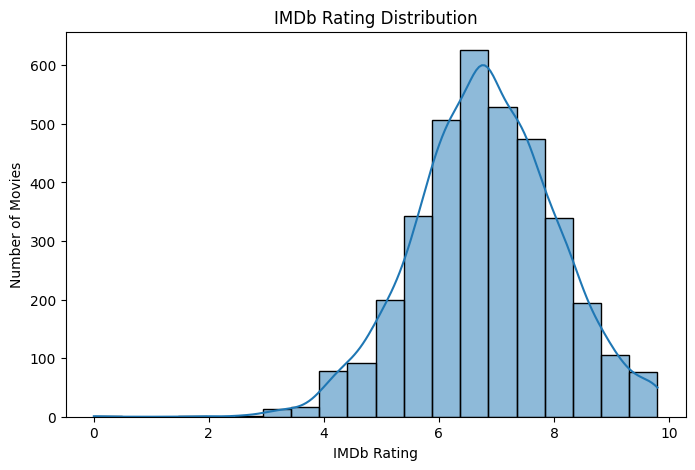

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["imdb_rating"],
    bins=20,
    kde=True
)

plt.title("IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")

plt.show()

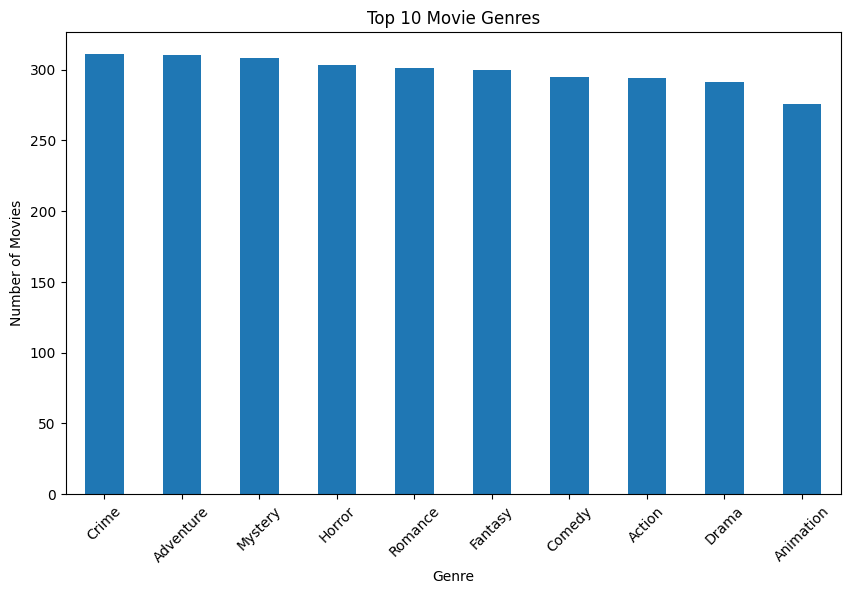

In [ ]:
plt.figure(figsize=(10,6))

df["genre"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

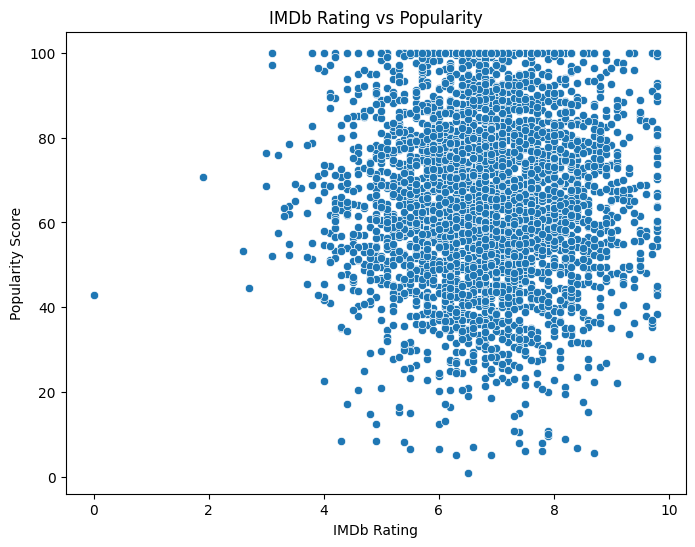

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="imdb_rating",
    y="popularity_score"
)

plt.title("IMDb Rating vs Popularity")
plt.xlabel("IMDb Rating")
plt.ylabel("Popularity Score")

plt.show()

In [ ]:
df["combined_text"] = (
    df["genre"].astype(str) + " " +
    df["language"].astype(str) + " " +
    df["country"].astype(str) + " " +
    df["certificate"].astype(str) + " " +
    df["director"].astype(str) + " " +
    df["lead_actor"].astype(str) + " " +
    df["weather"].astype(str)
)

**TF-IDF**

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(
    df["combined_text"]
)

print("TF-IDF matrix shape:")
print(tfidf_matrix.shape)

TF-IDF matrix shape:
(3600, 529)


**Scale numerical features**

In [ ]:
numerical_features = [
    "release_year",
    "runtime_minutes",
    "imdb_rating",
    "vote_count",
    "popularity_score",
    "user_age_rating"
]

scaler = StandardScaler()

numeric_matrix = scaler.fit_transform(
    df[numerical_features]
)

print(numeric_matrix.shape)

(3600, 6)


**TF-IDF + Numerical features**

In [ ]:
from scipy.sparse import csr_matrix, hstack

numeric_sparse = csr_matrix(numeric_matrix)

# Weight for numerical features
NUMERIC_WEIGHT = 0.30

combined_matrix = hstack([
    tfidf_matrix,
    numeric_sparse * NUMERIC_WEIGHT
]).tocsr()

print("Final feature matrix:")
print(combined_matrix.shape)

Final feature matrix:
(3600, 535)


In [ ]:
cosine_matrix = cosine_similarity(
    combined_matrix
)

print("Cosine similarity matrix:")
print(cosine_matrix.shape)

Cosine similarity matrix:
(3600, 3600)


In [ ]:
movie_index = pd.Series(
    df.index,
    index=df["title"].str.lower()
)

**Movie recommendation**

In [ ]:
def recommend_similar_movies(
    movie_title,
    top_n=10
):

    movie_title = movie_title.lower().strip()

    if movie_title not in movie_index:
        print("Movie not found.")
        return None

    idx = movie_index[movie_title]

    scores = list(
        enumerate(cosine_matrix[idx])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for movie_idx, score in scores[1:top_n+1]:

        recommendations.append({
            "Title": df.iloc[movie_idx]["title"],
            "Genre": df.iloc[movie_idx]["genre"],
            "Language": df.iloc[movie_idx]["language"],
            "Release Year": int(
                df.iloc[movie_idx]["release_year"]
            ),
            "IMDb Rating": round(
                df.iloc[movie_idx]["imdb_rating"],
                2
            ),
            "Popularity": round(
                df.iloc[movie_idx]["popularity_score"],
                2
            ),
            "Director": df.iloc[movie_idx]["director"],
            "Lead Actor": df.iloc[movie_idx]["lead_actor"],
            "Similarity Score": round(
                score,
                4
            )
        })

    return pd.DataFrame(recommendations)

In [ ]:
def recommend_movies(
    genre=None,
    language=None,
    country=None,
    min_imdb=None,
    release_year=None,
    max_runtime=None,
    certificate=None,
    director=None,
    lead_actor=None,
    age_preference=None,
    weather=None,
    top_n=10
):

    candidates = df.copy()

    if min_imdb is not None:
        candidates = candidates[
            candidates["imdb_rating"] >= min_imdb
        ]

    if release_year is not None:
        candidates = candidates[
            candidates["release_year"] == release_year
        ]

    if max_runtime is not None:
        candidates = candidates[
            candidates["runtime_minutes"] <= max_runtime
        ]

    if age_preference is not None:
        candidates = candidates[
            candidates["user_age_rating"] <= age_preference
        ]
    if len(candidates) == 0:
        print(
            "No movies match all the entered filters."
        )
        return pd.DataFrame()

    user_words = []

    preferences = [
        genre,
        language,
        country,
        certificate,
        director,
        lead_actor,
        weather
    ]

    for value in preferences:

        if value is not None:
            user_words.append(str(value))

    user_text = " ".join(user_words)

    if user_text.strip():

        user_tfidf = tfidf.transform(
            [user_text]
        )

        candidate_tfidf = tfidf.transform(
            candidates["combined_text"]
        )

        text_similarity = cosine_similarity(
            user_tfidf,
            candidate_tfidf
        )[0]

    else:

        text_similarity = np.zeros(
            len(candidates)
        )

    numeric_scores = np.zeros(
        len(candidates)
    )

    count = 0

    if min_imdb is not None:

        numeric_scores += (
            candidates["imdb_rating"] >= min_imdb
        ).astype(float)

        count += 1

    if release_year is not None:

        numeric_scores += (
            candidates["release_year"] == release_year
        ).astype(float)

        count += 1

    if max_runtime is not None:

        numeric_scores += (
            candidates["runtime_minutes"] <= max_runtime
        ).astype(float)

        count += 1

    if age_preference is not None:

        numeric_scores += (
            candidates["user_age_rating"]
            <= age_preference
        ).astype(float)

        count += 1

    if count > 0:

        numeric_scores = (
            numeric_scores / count
        )

    final_score = (
        0.75 * text_similarity +
        0.25 * numeric_scores
    )

    candidates = candidates.copy()

    candidates["similarity_score"] = final_score

    candidates = candidates.sort_values(
        by="similarity_score",
        ascending=False
    )

    result = candidates.head(top_n)[[
        "title",
        "genre",
        "language",
        "release_year",
        "imdb_rating",
        "popularity_score",
        "director",
        "lead_actor",
        "similarity_score"
    ]].copy()

    result.columns = [
        "Movie Title",
        "Genre",
        "Language",
        "Release Year",
        "IMDb Rating",
        "Popularity Score",
        "Director",
        "Lead Actor",
        "Recommendation Score"
    ]

    result["Recommendation Score"] = (
        result["Recommendation Score"]
        .round(4)
    )

    return result

In [ ]:
recommend_movies(
    genre="Action",
    language="English",
    country="USA",
    min_imdb=7,
    max_runtime=150,
    certificate="UA",
    weather="Hot",
    top_n=10
)

,Movie Title,Genre,Language,Release Year,IMDb Rating,Popularity Score,Director,Lead Actor,Recommendation Score
1664,The Great Escape,Action,English,1999.0,8.1,82.4,Arjun Rao,Kiran,0.6452
1891,The Final Mission 73,Action,English,2007.0,8.0,75.0,M. Wilson,Sophia,0.5221
2000,The Last Letter,Action,English,2005.0,9.6,83.8,Priya Kumar,Alex,0.5159
1396,Code Zero 2,Action,English,1998.0,8.4,45.4,M. Wilson,Sophia,0.5102
783,Love in Monsoon,Action,English,2013.0,7.1,51.7,S. Varma,Meera,0.5008
2733,Beyond the Valley,Action,English,1995.0,8.0,61.1,Ananya Sen,Vikram,0.4895
3259,Lost in Mumbai,Action,English,2024.0,9.1,75.8,Ananya Sen,Meera,0.4862
2337,Parallel Worlds 86,Thriller,English,2007.0,8.7,82.1,Priya Kumar,Daniel,0.4820
186,Dream Catcher,Horror,English,1995.0,7.5,31.6,Priya Kumar,Aarav,0.4772
468,The Last Letter 82,Horror,English,2017.0,8.1,93.3,John Carter,Meera,0.4741


In [ ]:
recommend_movies(
    genre="Comedy",
    top_n=10
)

,Movie Title,Genre,Language,Release Year,IMDb Rating,Popularity Score,Director,Lead Actor,Recommendation Score
2689,Echoes of Time,Comedy,English,2001.0,6.7,100.0,M. Wilson,Ananya,0.1882
1083,A New Beginning 96,Comedy,Telugu,2018.0,6.0,80.8,M. Wilson,Alex,0.1878
1467,City of Dreams,Comedy,English,1999.0,6.4,91.5,S. Varma,Ananya,0.1878
62,Ocean of Stars 30,Comedy,English,2017.0,6.8,59.7,S. Varma,Daniel,0.1867
1277,Starlight,Comedy,Malayalam,2021.0,7.3,57.1,M. Wilson,Ananya,0.1866
445,Golden Promise 62,Comedy,Telugu,2024.0,6.6,47.6,S. Varma,Ananya,0.1865
3548,Code Zero 99,Comedy,Japanese,2000.0,4.9,88.0,M. Wilson,Rahul,0.1864
2517,Family Ties,Comedy,Hindi,2019.0,4.2,56.5,S. Varma,Riya,0.1864
2292,Kingdom of Ash,Comedy,Malayalam,1995.0,7.4,47.2,S. Varma,Riya,0.1863
2321,The Missing Piece 91,Comedy,Japanese,2003.0,6.8,64.2,S. Varma,Meera,0.1863


In [ ]:
recommend_movies(
    genre="Drama",
    min_imdb=7.5,
    top_n=10
)

,Movie Title,Genre,Language,Release Year,IMDb Rating,Popularity Score,Director,Lead Actor,Recommendation Score
400,Lost in Mumbai 58,Drama,Telugu,1995.0,8.2,43.5,S. Varma,Daniel,0.4380
3030,Kingdom of Ash 3,Drama,Telugu,1996.0,8.0,75.3,M. Wilson,Aarav,0.4373
1468,Midnight Train,Drama,Korean,2018.0,7.5,71.2,S. Varma,Meera,0.4363
1720,Journey Home 78,Drama,Telugu,2008.0,8.2,86.2,M. Wilson,Riya,0.4359
1447,The Last Letter 74,Drama,Tamil,2006.0,7.8,53.6,M. Wilson,Riya,0.4353
2448,Shadow Protocol 33,Drama,Hindi,2005.0,8.1,29.8,S. Varma,Alex,0.4344
2433,Crimson Sky 59,Drama,Hindi,2025.0,7.7,67.2,M. Wilson,Daniel,0.4325
3174,The Silent Witness 12,Drama,Kannada,2019.0,7.6,51.5,M. Wilson,Vikram,0.4325
1844,The Missing Piece,Drama,Tamil,2000.0,9.8,60.0,M. Wilson,Aarav,0.4322
1586,A New Beginning 69,Drama,English,2009.0,8.3,70.2,S. Varma,Aarav,0.4313


In [ ]:
recommend_movies(
    director="Arjun Rao",
    top_n=10
)

,Movie Title,Genre,Language,Release Year,IMDb Rating,Popularity Score,Director,Lead Actor,Recommendation Score
1432,The Silent Witness,Adventure,Korean,2018.0,8.6,63.4,Arjun Rao,Daniel,0.2728
146,Digital Hearts 76,Adventure,Korean,2012.0,7.2,64.0,Arjun Rao,Ananya,0.2713
3407,Broken Compass 85,Crime,Japanese,2003.0,5.5,85.7,Arjun Rao,Sophia,0.2710
1013,The Last Horizon 30,Fantasy,Hindi,2023.0,8.4,76.4,Arjun Rao,Meera,0.2703
722,Echoes of Time 5,Adventure,Korean,1999.0,4.5,46.4,Arjun Rao,Alex,0.2701
639,The Great Escape,Crime,Tamil,2001.0,7.8,81.0,Arjun Rao,Ananya,0.2700
3087,Love in Monsoon 15,Adventure,Korean,2004.0,9.8,45.1,Arjun Rao,Aarav,0.2699
2789,Lost in Mumbai,Crime,Tamil,2015.0,7.1,68.6,Arjun Rao,Ananya,0.2698
2632,Dream Catcher 38,Drama,English,2002.0,7.0,51.8,Arjun Rao,Daniel,0.2695
2746,The Last Horizon 64,Horror,Malayalam,2000.0,8.3,49.5,Arjun Rao,Rahul,0.2695
